# Step 02: Data Preparation & N=32 Resampling

Applies spatial outlier filtering, initial frame centroid coordinate shift ($\Delta x, \Delta y$), and uniform random resampling ($N=32$ points) to generate leak-free training tensors (`X_train.npy`, 1:1 balanced), validation tensors (`X_val.npy`, natural distribution), and testing tensors (`X_test.npy`, unseen test set).

### Preprocessing Pipeline Steps:
1. **Outlier Filtering**: Filters spatial noise outside room box $X \in [-2, 2], Y \in [0, 6], Z \in [-0.5, 2.2]$ m and low SNR ($< 100$).
2. **Coordinate Shift**: Shifts coordinates relative to initial frame centroid: $[\Delta x, \Delta y, z, v]$.
3. **Uniform Random Resampling ($N=32$)**: Standardizes sparse reflection points (5–20 pts) to exact $N=32$ points per frame using persistent `rng`.

In [5]:
%load_ext autoreload
%autoreload 2
import sys, importlib; sys.path.append("..") if ".." not in sys.path else None
import json
import src.config, src.dataset_utils, src.pipeline, src.trainer
importlib.reload(src.config)
importlib.reload(src.dataset_utils)
importlib.reload(src.pipeline)
importlib.reload(src.trainer)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.pipeline import run_data_preparation
from src.config import DATASET_CONFIGS

sns.set_theme(style="whitegrid")

# Select target dataset: "mmfall" | "mmwave" | "combined"
dataset_key = "mmfall"

# Execute data preparation pipeline
X_train, y_train, X_val, y_val, X_test, y_test = run_data_preparation(dataset_key)

print(f"\n=== Preprocessing Complete ({DATASET_CONFIGS[dataset_key].name}) ===")
print(f"Training Matrix Shape:   {X_train.shape} (Balanced 1:1)")
print(f"Validation Matrix Shape: {X_val.shape}   (Natural Distribution)")
print(f"Testing Matrix Shape:    {X_test.shape}   (Unseen Holdout Test)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Step 02 Preprocessing Complete for 'mmFall (TI IWR1443)':
  Train Tensors: (1220, 10, 32, 4) (Labels: [610 610])
  Val Tensors:   (12611, 10, 32, 4) (Labels: [12487   124])
  Test Tensors:  (2357, 10, 32, 4) (Labels: [2205  152])

=== Preprocessing Complete (mmFall (TI IWR1443)) ===
Training Matrix Shape:   (1220, 10, 32, 4) (Balanced 1:1)
Validation Matrix Shape: (12611, 10, 32, 4)   (Natural Distribution)
Testing Matrix Shape:    (2357, 10, 32, 4)   (Unseen Holdout Test)


C:\Users\joeyw\AppData\Local\Temp\ipykernel_4952\1533038280.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels([" ADL (0)", " Fall (1)"])


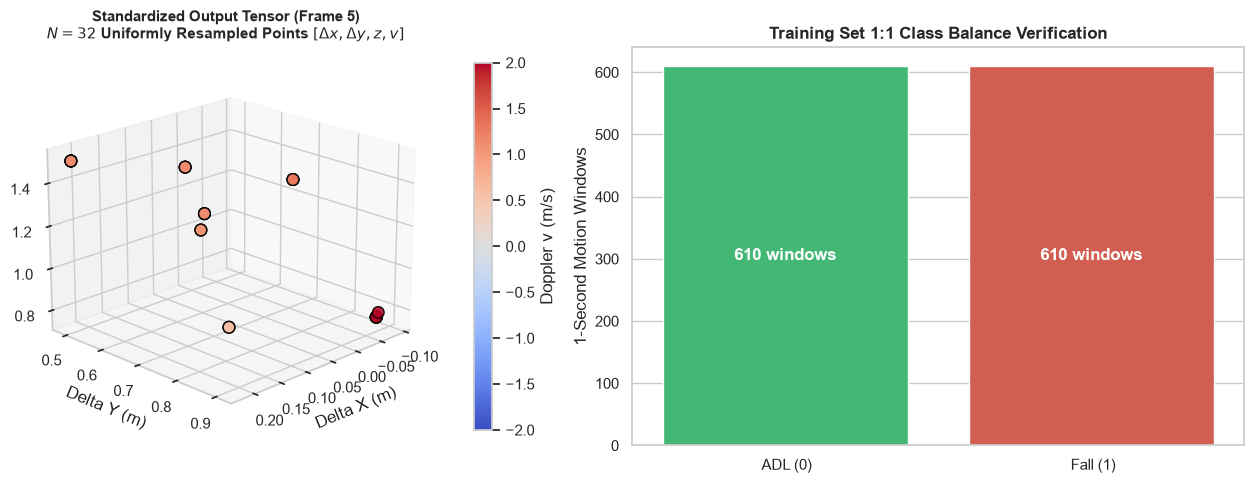

In [6]:
# Visual Showcase 1: Raw Sparse Point Frame vs. Standardized N=32 Resampled Output
sample_clip = X_train[0, 5] # Clip 0, Frame 5
fig = plt.figure(figsize=(14, 5), dpi=100)

# 3D Resampled Tensor
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(sample_clip[:, 0], sample_clip[:, 1], sample_clip[:, 2], c=sample_clip[:, 3], cmap='coolwarm', s=70, edgecolors='black', vmin=-2, vmax=2)
ax1.set_title(f"Standardized Output Tensor (Frame 5)\n$N = {len(sample_clip)}$ Uniformly Resampled Points $[\\Delta x, \\Delta y, z, v]$", fontweight='bold', fontsize=11)
ax1.set_xlabel("Delta X (m)"); ax1.set_ylabel("Delta Y (m)"); ax1.set_zlabel("Z (m)")
fig.colorbar(sc1, ax=ax1, fraction=0.03, pad=0.08, label="Doppler v (m/s)")
ax1.view_init(elev=20, azim=45)

# Class Distribution Bar Chart
ax2 = fig.add_subplot(1, 2, 2)
sns.countplot(x=y_train, hue=y_train, ax=ax2, palette=["#2ecc71", "#e74c3c"], legend=False)
ax2.set_xticklabels([" ADL (0)", " Fall (1)"])
ax2.set_title("Training Set 1:1 Class Balance Verification", fontweight="bold", fontsize=12)
ax2.set_ylabel("1-Second Motion Windows")
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height())} windows", (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha="center", va="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()